# Laboratorio 04 — Clasificación Multiclase One-vs-All con PyTorch
## Dataset: CICIDS2017 — Cleaned & Preprocessed

### Dataset
El dataset **CICIDS2017: Cleaned & Preprocessed** contiene registros de tráfico de red con:
- **52 características numéricas**: duración del flujo, longitud de paquetes, puertos, flags TCP, etc.
- **Más de 2 millones de ejemplos**
- **Columna objetivo `Attack Type`**: tráfico BENIGN o distintos tipos de ataques (DoS, DDoS, PortScan, etc.)

URL del dataset:  
[https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed](https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed)

## 1. Importación de Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Selección automática de dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
print(torch.cuda.get_device_name(0))

Dispositivo: cuda
NVIDIA GeForce RTX 2060


## 2. Carga y Exploración del Dataset

In [2]:
# ── Opción A: Google Colab con Drive ─────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/cicids2017_cleaned.csv')

# ── Opción B: ruta local (Windows) ───────────────────────────────────────────
df = pd.read_csv("cicids2017_cleaned.csv")

print(f'Shape del dataset: {df.shape}')
df.head()

Shape del dataset: (2520751, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [3]:
# Columnas disponibles
COLUMNA_OBJETIVO = 'Attack Type'

print(f'Total de columnas: {len(df.columns)}')
conteo_original = df[COLUMNA_OBJETIVO].value_counts()
print(f"\nDistribución de '{COLUMNA_OBJETIVO}':")
print(conteo_original)
print(f'\nTotal de categorías: {len(conteo_original)}')

Total de columnas: 53

Distribución de 'Attack Type':
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

Total de categorías: 7


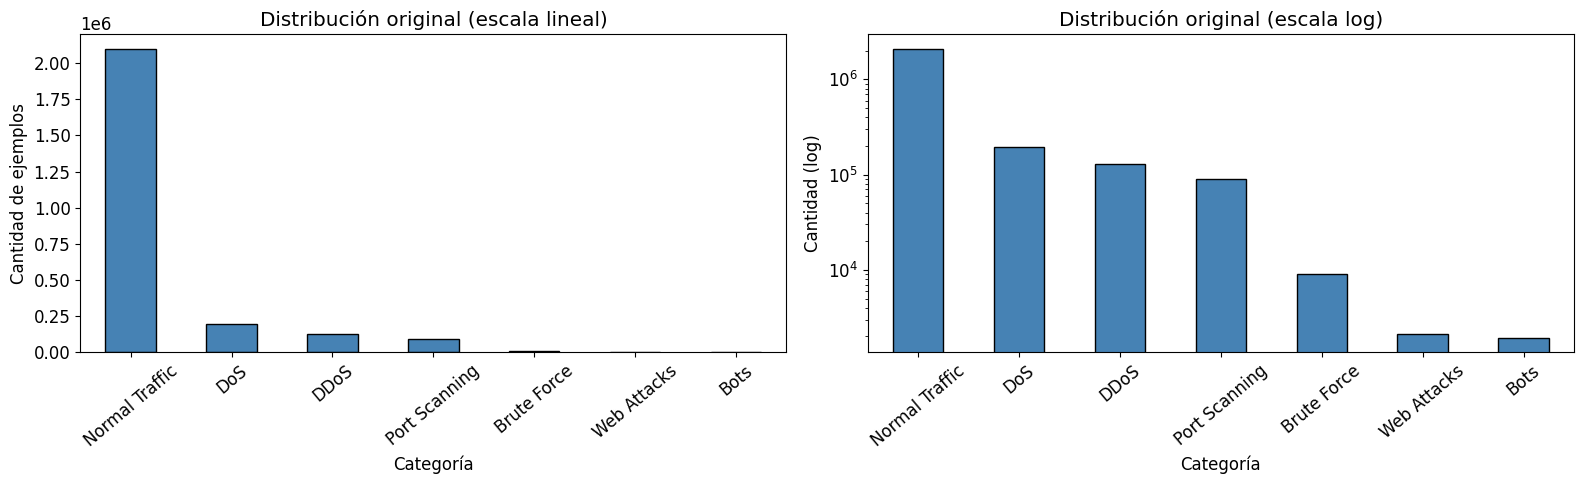

In [4]:
# Gráfica de distribución original
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

conteo_original.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Distribución original (escala lineal)")
axes[0].set_xlabel('Categoría'); axes[0].set_ylabel('Cantidad de ejemplos')
axes[0].tick_params(axis='x', rotation=40)

conteo_original.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', logy=True)
axes[1].set_title("Distribución original (escala log)")
axes[1].set_xlabel('Categoría'); axes[1].set_ylabel('Cantidad (log)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento

### Balance de clases

In [5]:
# ── Mapeo de etiquetas ────────────────────────────────────────────────────
mapeo_clases = {
    'Normal Traffic' : 0,   # Clase 0 — Tráfico normal
    'DoS'            : 1,   # Clase 1 — DoS/DDoS
    'DDoS'           : 1,
    'Port Scanning'  : 2,   # Clase 2 — Otros ataques
    'Brute Force'    : 2,
    'Web Attacks'    : 2,
    'Bots'           : 2,
}

mapa_nombres = {0: 'Normal Traffic', 1: 'DoS/DDoS', 2: 'Otros ataques'}
NUM_CLASES   = 3
COLORES      = ['royalblue', 'darkorange', 'forestgreen']

df['y_encoded'] = df[COLUMNA_OBJETIVO].map(mapeo_clases)
df.dropna(subset=['y_encoded'], inplace=True)
df['y_encoded'] = df['y_encoded'].astype(int)

print('Distribución de clases agrupadas:')
for c, nom in mapa_nombres.items():
    n   = (df['y_encoded'] == c).sum()
    pct = n / len(df) * 100
    print(f'  Clase {c} - {nom:<18}: {n:>10,} ejemplos ({pct:5.2f}%)')
print(f'\n  Total: {len(df):,} ejemplos')

Distribución de clases agrupadas:
  Clase 0 - Normal Traffic    :  2,095,057 ejemplos (83.11%)
  Clase 1 - DoS/DDoS          :    321,759 ejemplos (12.76%)
  Clase 2 - Otros ataques     :    103,935 ejemplos ( 4.12%)

  Total: 2,520,751 ejemplos


In [6]:
# ── Selección de características
columnas_excluir = [COLUMNA_OBJETIVO, 'y_encoded']
columnas_X = [c for c in df.select_dtypes(include=[np.number]).columns
              if c not in columnas_excluir]

print(f'Características numéricas seleccionadas: {len(columnas_X)}')

Características numéricas seleccionadas: 52


In [7]:
# ── Submuestreo balanceado
disponibles = {c: int((df['y_encoded'] == c).sum()) for c in range(NUM_CLASES)}
print('Ejemplos disponibles por clase:')
for c, n in disponibles.items():
    print(f'  Clase {c} ({mapa_nombres[c]:<18}): {n:>10,}')

TOPE_POR_CLASE = 100000

n_por_clase = min(TOPE_POR_CLASE, min(disponibles.values()))
print(f'\nMuestras tomadas por clase: {n_por_clase:,}')

partes  = [df[df['y_encoded'] == c].sample(n=n_por_clase, random_state=42)
           for c in range(NUM_CLASES)]
df_bal  = pd.concat(partes, ignore_index=True)
df_bal  = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataset balanceado: {df_bal.shape[0]:,} ejemplos × {len(columnas_X)} características')

Ejemplos disponibles por clase:
  Clase 0 (Normal Traffic    ):  2,095,057
  Clase 1 (DoS/DDoS          ):    321,759
  Clase 2 (Otros ataques     ):    103,935

Muestras tomadas por clase: 100,000

Dataset balanceado: 300,000 ejemplos × 52 características


### Separación entrenamiento / prueba

In [8]:
# ── Split entrenamiento / prueba (80/20) ──────────────────────────────────
X_total = df_bal[columnas_X].values.astype(np.float32)
y_total = df_bal['y_encoded'].values.astype(np.int64)   # long para CrossEntropyLoss

m_total    = X_total.shape[0]
n_features = X_total.shape[1]

np.random.seed(42)
indices   = np.random.permutation(m_total)
corte     = int(0.80 * m_total)

X_train_raw, y_train = X_total[indices[:corte]],  y_total[indices[:corte]]
X_test_raw,  y_test  = X_total[indices[corte:]], y_total[indices[corte:]]

print(f'Entrenamiento: {X_train_raw.shape[0]:,} ejemplos  (80%)')
print(f'Prueba:        {X_test_raw.shape[0]:,}  ejemplos  (20%)')
print(f'Características (n): {n_features}')

Entrenamiento: 240,000 ejemplos  (80%)
Prueba:        60,000  ejemplos  (20%)
Características (n): 52


### Normalización

In [9]:
# ── Normalización Z-score (calculada solo sobre train) ───────────────────
mu    = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1   # evitar división por cero en columnas constantes

X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw  - mu) / sigma

print('Normalización completada:')
print(f'  Media global X_train normalizado:  {X_train.mean():.8f}  (≈ 0)')
print(f'  Std  global X_train normalizado:   {X_train.std():.8f}   (≈ 1)')

Normalización completada:
  Media global X_train normalizado:  0.00003646  (≈ 0)
  Std  global X_train normalizado:   1.00002599   (≈ 1)


## 4. Dataset y DataLoader (PyTorch)

En lugar de pasar arrays completos al modelo, usamos las clases `Dataset` y `DataLoader` de PyTorch. Esto nos da mini-batches automáticos, mezclado de datos en cada época, y carga eficiente.

In [10]:
class CICIDSDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Convertimos los arrays NumPy a tensores de PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)      # long requerido por CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
# ── Instanciar datasets ───────────────────────────────────────────────────────
train_dataset = CICIDSDataset(X_train, y_train)
test_dataset  = CICIDSDataset(X_test,  y_test)

# ── Instanciar dataloaders ────────────────────────────────────────────────────
BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=(device=='cuda'))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=(device=='cuda'))

print(f'Batches por época (train): {len(train_loader):,}')
print(f'Batches por época (test):  {len(test_loader):,}')

# Verificar un batch
x_b, y_b = next(iter(train_loader))
print(f'\nForma de un batch  →  X: {x_b.shape}   y: {y_b.shape}')

Batches por época (train): 469
Batches por época (test):  118

Forma de un batch  →  X: torch.Size([512, 52])   y: torch.Size([512])


## 5. Definición del Modelo

El clasificador One-vs-All en PyTorch se implementa como una red con **una capa lineal y N salidas** (una por clase). `CrossEntropyLoss` internamente aplica Softmax sobre las salidas y calcula la entropía cruzada, equivalente a entrenar K clasificadores logísticos simultáneamente.

In [ ]:
class ClasificadorOvA(nn.Module):
    def __init__(self, n_features: int, n_clases: int):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, n_clases)    # logits crudos — sin Softmax aquí
        )

    def forward(self, x):
        return self.red(x)

In [13]:
model = ClasificadorOvA(n_features=n_features, n_clases=NUM_CLASES).to(device)
print(model)

# Número total de parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

ClasificadorOvA(
  (red): Sequential(
    (0): Linear(in_features=52, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

Parámetros entrenables: 7,171


## 6. Entrenamiento con Checkpoints

Definimos los hiperparámetros y el ciclo de entrenamiento. La regularización L2 (`weight_decay`) se pasa directamente al optimizador, reemplazando el cálculo manual del original.

Al final de cada época se guarda un **checkpoint** con `state_dict`, la época y el loss, lo que permite retomar el entrenamiento en cualquier punto.

In [14]:
# ── Hiperparámetros ───────────────────────────────────────────────────────────
LR           = 0.001   # Tasa de aprendizaje (equivalente al alpha original)
EPOCHS       = 20      # Épocas de entrenamiento
WEIGHT_DECAY = 0.1     # Regularización L2 (equivalente al lambda original)
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Función de pérdida y optimizador ─────────────────────────────────────────
# CrossEntropyLoss equivale a aplicar Softmax + log + NLLLoss.
# Internamente hace lo mismo que los K clasificadores binarios del original.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f'Dispositivo      : {device}')
print(f'Épocas           : {EPOCHS}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Learning rate    : {LR}')
print(f'Weight decay (L2): {WEIGHT_DECAY}')
print(f'Checkpoints en   : {CHECKPOINT_DIR}/')

Dispositivo      : cuda
Épocas           : 20
Batch size       : 512
Learning rate    : 0.001
Weight decay (L2): 0.1
Checkpoints en   : ./checkpoints/


In [15]:
def evaluar(model, loader, criterion, device):
    """Calcula loss y accuracy sobre un DataLoader completo sin actualizar pesos."""
    model.eval()
    total_loss, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            logits   = model(x_b)
            loss     = criterion(logits, y_b)
            total_loss += loss.item() * len(y_b)
            preds      = logits.argmax(dim=1)
            correctos  += (preds == y_b).sum().item()
            total      += len(y_b)
    return total_loss / total, correctos / total * 100

In [16]:
# ── Ciclo de entrenamiento ────────────────────────────────────────────────────
historial = {'epoch': [], 'loss_train': [], 'loss_test': [],
             'acc_train': [], 'acc_test': []}

print('Iniciando entrenamiento One-vs-All con PyTorch...')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    # ── Fase de entrenamiento ──
    model.train()
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        logits = model(x_b)             # 1. Forward pass
        loss   = criterion(logits, y_b) # 2. Calcular pérdida

        optimizer.zero_grad()           # 3. Limpiar gradientes
        loss.backward()                 # 4. Backward pass
        optimizer.step()                # 5. Actualizar pesos

    # ── Evaluación al final de cada época ──
    loss_tr, acc_tr = evaluar(model, train_loader, criterion, device)
    loss_te, acc_te = evaluar(model, test_loader,  criterion, device)

    historial['epoch'].append(epoch)
    historial['loss_train'].append(loss_tr)
    historial['loss_test'].append(loss_te)
    historial['acc_train'].append(acc_tr)
    historial['acc_test'].append(acc_te)

    print(f'Epoch {epoch:3d}/{EPOCHS}  '
          f'Loss: train={loss_tr:.5f}  test={loss_te:.5f}  '
          f'Acc: train={acc_tr:.2f}%  test={acc_te:.2f}%')

    # ── Guardar checkpoint ────────────────────────────────────────────────────
    checkpoint = {
        'epoch'      : epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'loss_test'  : loss_te,
        'acc_test'   : acc_te,
    }
    torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch:02d}.pt'))

print('=' * 70)
print('Entrenamiento completado.')
print(f'Checkpoints guardados en: {CHECKPOINT_DIR}/')

Iniciando entrenamiento One-vs-All con PyTorch...
Epoch   1/20  Loss: train=0.35265  test=0.35176  Acc: train=89.11%  test=89.23%
Epoch   2/20  Loss: train=0.35131  test=0.35054  Acc: train=88.71%  test=88.78%
Epoch   3/20  Loss: train=0.34918  test=0.34820  Acc: train=90.02%  test=90.14%
Epoch   4/20  Loss: train=0.34652  test=0.34552  Acc: train=89.67%  test=89.75%
Epoch   5/20  Loss: train=0.35035  test=0.34938  Acc: train=89.76%  test=89.85%
Epoch   6/20  Loss: train=0.35313  test=0.35209  Acc: train=90.83%  test=90.90%
Epoch   7/20  Loss: train=0.35233  test=0.35147  Acc: train=89.42%  test=89.46%
Epoch   8/20  Loss: train=0.35149  test=0.35054  Acc: train=89.94%  test=90.04%
Epoch   9/20  Loss: train=0.34632  test=0.34537  Acc: train=89.98%  test=90.09%
Epoch  10/20  Loss: train=0.35271  test=0.35174  Acc: train=90.03%  test=90.14%
Epoch  11/20  Loss: train=0.35132  test=0.35048  Acc: train=89.06%  test=89.13%
Epoch  12/20  Loss: train=0.35278  test=0.35198  Acc: train=89.27%  te

## 7. Carga de Checkpoint

Así se retoma el entrenamiento o se carga el mejor modelo guardado.

In [17]:
# Cargar el checkpoint de la última época (o del mejor)
PATH_CHECKPOINT = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{EPOCHS:02d}.pt')

checkpoint = torch.load(PATH_CHECKPOINT, map_location=device)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optim_state'])

print(f'Checkpoint cargado: época {checkpoint["epoch"]}')
print(f'  Loss test : {checkpoint["loss_test"]:.5f}')
print(f'  Acc  test : {checkpoint["acc_test"]:.2f}%')

# Poner en modo evaluación para hacer predicciones
model.eval()
print('\nModelo listo para predicción (model.eval())')

Checkpoint cargado: época 20
  Loss test : 0.34717
  Acc  test : 90.05%

Modelo listo para predicción (model.eval())


## 8. Curvas de Entrenamiento

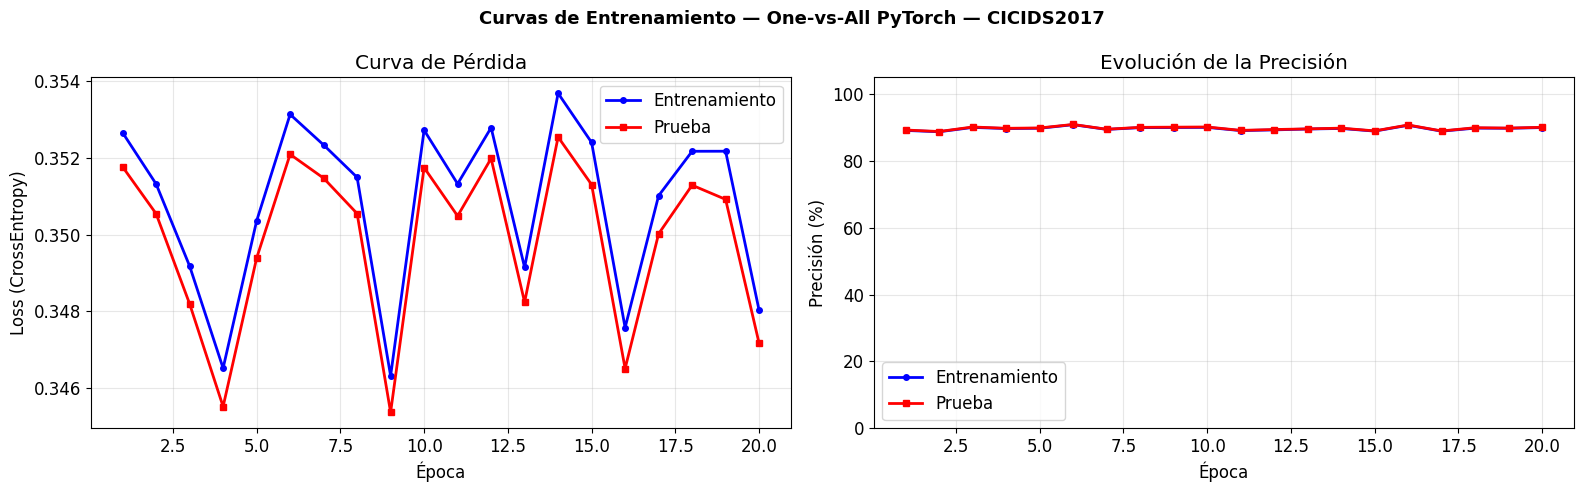

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Curva de pérdida
axes[0].plot(historial['epoch'], historial['loss_train'], 'b-o', ms=4, lw=2, label='Entrenamiento')
axes[0].plot(historial['epoch'], historial['loss_test'],  'r-s', ms=4, lw=2, label='Prueba')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].set_title('Curva de Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de accuracy
axes[1].plot(historial['epoch'], historial['acc_train'], 'b-o', ms=4, lw=2, label='Entrenamiento')
axes[1].plot(historial['epoch'], historial['acc_test'],  'r-s', ms=4, lw=2, label='Prueba')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión (%)')
axes[1].set_title('Evolución de la Precisión')
axes[1].set_ylim([0, 105])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — One-vs-All PyTorch — CICIDS2017',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluación y Métricas

In [19]:
def obtener_predicciones(model, loader, device):
    """Recorre todo el DataLoader y devuelve predicciones, etiquetas reales y probabilidades."""
    model.eval()
    preds_list, labels_list, probs_list = [], [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b      = x_b.to(device)
            logits   = model(x_b)
            probs    = torch.softmax(logits, dim=1)
            preds    = logits.argmax(dim=1)
            preds_list.append(preds.cpu().numpy())
            labels_list.append(y_b.numpy())
            probs_list.append(probs.cpu().numpy())
    return (np.concatenate(preds_list),
            np.concatenate(labels_list),
            np.concatenate(probs_list, axis=0))


pred_train, y_train_np, prob_train = obtener_predicciones(model, train_loader, device)
pred_test,  y_test_np,  prob_test  = obtener_predicciones(model, test_loader,  device)

prec_train = np.mean(pred_train == y_train_np) * 100
prec_test  = np.mean(pred_test  == y_test_np)  * 100

print(f'Precisión global — Entrenamiento: {prec_train:.2f}%')
print(f'Precisión global — Prueba:        {prec_test:.2f}%')

Precisión global — Entrenamiento: 89.97%
Precisión global — Prueba:        90.05%


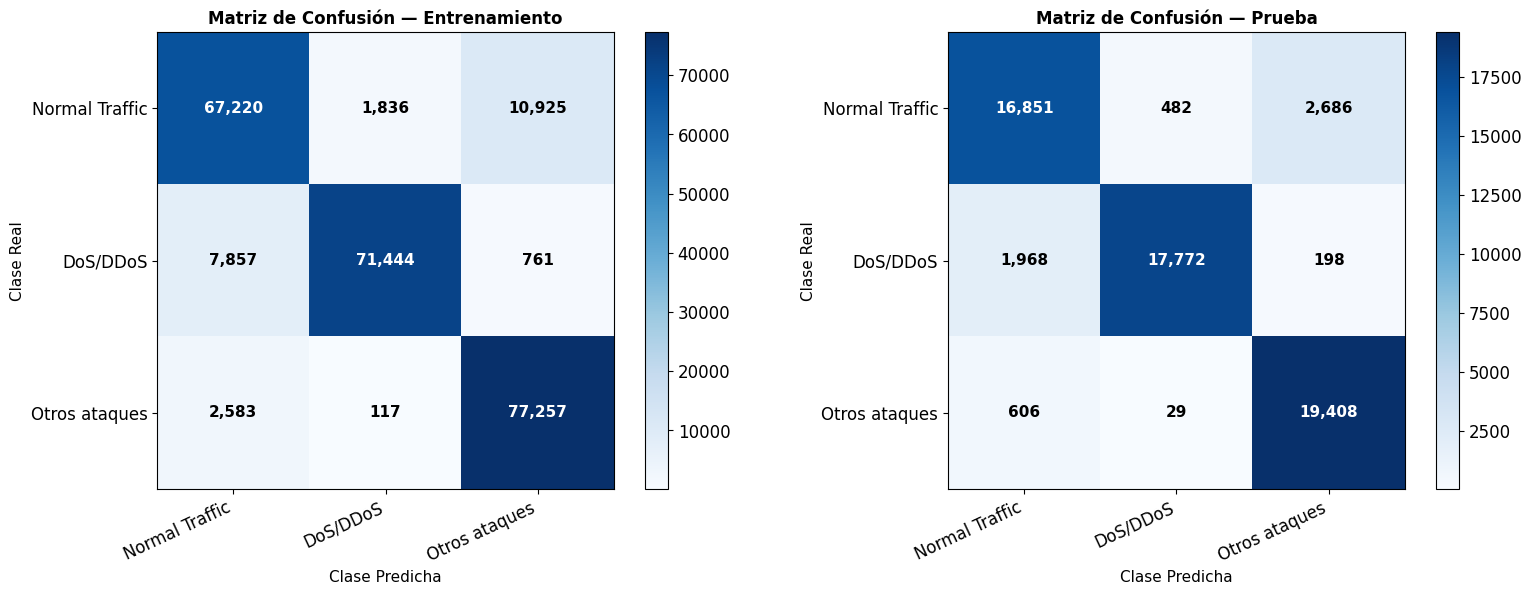

In [20]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
def matriz_confusion(y_real, y_pred, k):
    mc = np.zeros((k, k), dtype=int)
    for r, p in zip(y_real.astype(int), y_pred.astype(int)):
        mc[r][p] += 1
    return mc

mc_train = matriz_confusion(y_train_np, pred_train, NUM_CLASES)
mc_test  = matriz_confusion(y_test_np,  pred_test,  NUM_CLASES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mc, titulo in zip(axes, [mc_train, mc_test], ['Entrenamiento', 'Prueba']):
    im = ax.imshow(mc, cmap='Blues')
    plt.colorbar(im, ax=ax)
    etiquetas = [mapa_nombres[c] for c in range(NUM_CLASES)]
    ax.set_xticks(range(NUM_CLASES)); ax.set_xticklabels(etiquetas, rotation=25, ha='right')
    ax.set_yticks(range(NUM_CLASES)); ax.set_yticklabels(etiquetas)
    for i in range(NUM_CLASES):
        for j in range(NUM_CLASES):
            color = 'white' if mc[i, j] > mc.max() / 2 else 'black'
            ax.text(j, i, f'{mc[i,j]:,}', ha='center', va='center',
                    color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel('Clase Predicha', fontsize=11)
    ax.set_ylabel('Clase Real',     fontsize=11)
    ax.set_title(f'Matriz de Confusión — {titulo}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# ── Precision, Recall y F1 por clase ─────────────────────────────────────────
def metricas_por_clase(mc, nombres):
    print(f"{'Clase':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Soporte':>10}")
    print('-' * 64)
    f1s, pesos = [], []
    for i, nom in enumerate(nombres):
        tp  = mc[i, i]
        fp  = mc[:, i].sum() - tp
        fn  = mc[i, :].sum() - tp
        sup = int(mc[i, :].sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append(f1); pesos.append(sup)
        print(f'{nom:<20} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {sup:>10,}')
    print('-' * 64)
    print(f"{'Macro avg':<20} {'':>10} {'':>10} {np.mean(f1s):>10.4f} {mc.sum():>10,}")
    print(f"{'Weighted avg':<20} {'':>10} {'':>10} {np.average(f1s, weights=pesos):>10.4f} {mc.sum():>10,}")

nombres_clases = [mapa_nombres[i] for i in range(NUM_CLASES)]

print('Métricas — Conjunto de Entrenamiento')
print('=' * 64)
metricas_por_clase(mc_train, nombres_clases)

print()
print('Métricas — Conjunto de Prueba')
print('=' * 64)
metricas_por_clase(mc_test, nombres_clases)

Métricas — Conjunto de Entrenamiento
Clase                 Precision     Recall   F1-Score    Soporte
----------------------------------------------------------------
Normal Traffic           0.8656     0.8404     0.8528     79,981
DoS/DDoS                 0.9734     0.8924     0.9311     80,062
Otros ataques            0.8686     0.9662     0.9148     79,957
----------------------------------------------------------------
Macro avg                                      0.8996    240,000
Weighted avg                                   0.8996    240,000

Métricas — Conjunto de Prueba
Clase                 Precision     Recall   F1-Score    Soporte
----------------------------------------------------------------
Normal Traffic           0.8675     0.8418     0.8544     20,019
DoS/DDoS                 0.9721     0.8914     0.9300     19,938
Otros ataques            0.8706     0.9683     0.9169     20,043
----------------------------------------------------------------
Macro avg             

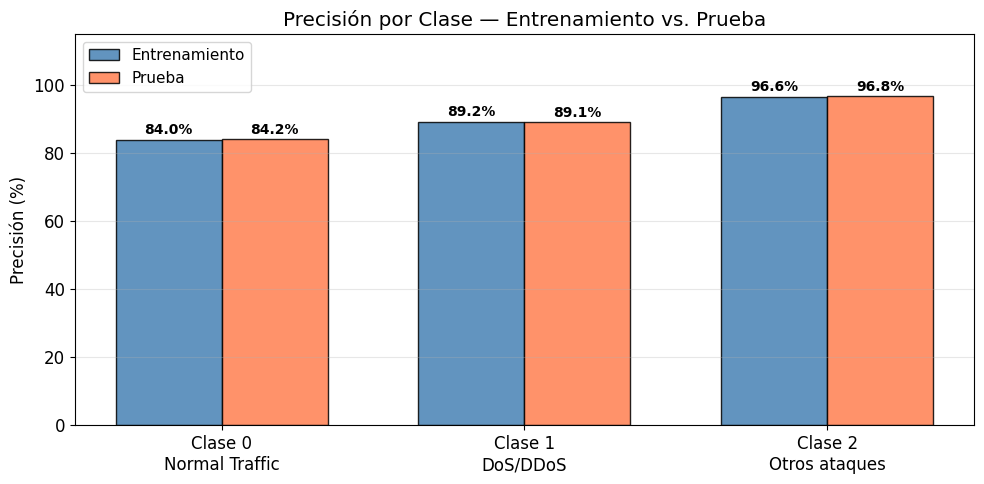

In [22]:
# ── Precisión por clase (barras) ──────────────────────────────────────────────
ptr = [np.mean(pred_train[y_train_np == c] == c) * 100 for c in range(NUM_CLASES)]
pte = [np.mean(pred_test[y_test_np   == c] == c) * 100 for c in range(NUM_CLASES)]

x, w = np.arange(NUM_CLASES), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, ptr, w, label='Entrenamiento', color='steelblue', edgecolor='black', alpha=0.85)
b2 = ax.bar(x + w/2, pte, w, label='Prueba',        color='coral',     edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Clase {c}\n{mapa_nombres[c]}' for c in range(NUM_CLASES)])
ax.set_ylabel('Precisión (%)')
ax.set_title('Precisión por Clase — Entrenamiento vs. Prueba')
ax.legend(fontsize=11)
ax.set_ylim([0, 115])
ax.grid(True, alpha=0.3, axis='y')

for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.1f}%',
                xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

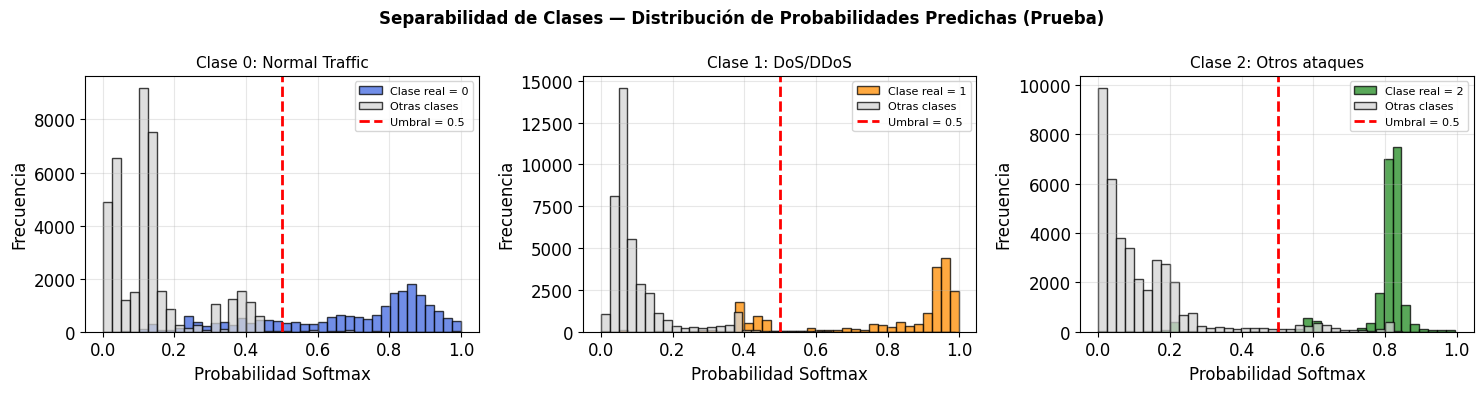

In [23]:
# ── Distribución de probabilidades por clase ──────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASES, figsize=(15, 4))

for c in range(NUM_CLASES):
    pos = (y_test_np == c)
    neg = ~pos
    axes[c].hist(prob_test[pos, c], bins=40, color=COLORES[c],
                 alpha=0.75, edgecolor='black', label=f'Clase real = {c}')
    axes[c].hist(prob_test[neg, c], bins=40, color='lightgray',
                 alpha=0.75, edgecolor='black', label='Otras clases')
    axes[c].axvline(0.5, color='red', lw=2, linestyle='--', label='Umbral = 0.5')
    axes[c].set_title(f'Clase {c}: {mapa_nombres[c]}', fontsize=11)
    axes[c].set_xlabel('Probabilidad Softmax')
    axes[c].set_ylabel('Frecuencia')
    axes[c].legend(fontsize=8)
    axes[c].grid(True, alpha=0.3)

plt.suptitle('Separabilidad de Clases — Distribución de Probabilidades Predichas (Prueba)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Resumen de Resultados

In [24]:
print('=' * 70)
print('   RESUMEN — CLASIFICADOR ONE-VS-ALL — CICIDS2017 (PyTorch)')
print('=' * 70)
print(f'Dataset:                  CICIDS2017 Cleaned & Preprocessed')
print(f'Columna objetivo:         {COLUMNA_OBJETIVO}')
print(f'Características (n):      {n_features}  (≥ 40 ✓)')
print(f'Ejemplos totales (m):     {m_total:,}  (≥ 50,000 ✓)')
print(f'  └─ Entrenamiento (80%): {X_train.shape[0]:,}')
print(f'  └─ Prueba (20%):        {X_test.shape[0]:,}')
print()
print('Clases del modelo:')
for c, nom in mapa_nombres.items():
    print(f'  {c} → {nom}')
print()
print('Arquitectura:')
print(f'  {model}')
print()
print('Hiperparámetros:')
print(f'  Tasa de aprendizaje (LR)  : {LR}')
print(f'  Épocas                    : {EPOCHS}')
print(f'  Batch size                : {BATCH_SIZE}')
print(f'  Regularización L2         : {WEIGHT_DECAY}')
print(f'  Optimizador               : Adam')
print(f'  Función de pérdida        : CrossEntropyLoss')
print(f'  Dispositivo               : {device}')
print()
print('Resultados finales:')
print(f'  Precisión en entrenamiento: {prec_train:.2f}%')
print(f'  Precisión en prueba:        {prec_test:.2f}%')
print()
print('Checkpoints guardados:')
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    print(f'  {os.path.join(CHECKPOINT_DIR, f)}')
print('=' * 70)

   RESUMEN — CLASIFICADOR ONE-VS-ALL — CICIDS2017 (PyTorch)
Dataset:                  CICIDS2017 Cleaned & Preprocessed
Columna objetivo:         Attack Type
Características (n):      52  (≥ 40 ✓)
Ejemplos totales (m):     300,000  (≥ 50,000 ✓)
  └─ Entrenamiento (80%): 240,000
  └─ Prueba (20%):        60,000

Clases del modelo:
  0 → Normal Traffic
  1 → DoS/DDoS
  2 → Otros ataques

Arquitectura:
  ClasificadorOvA(
  (red): Sequential(
    (0): Linear(in_features=52, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

Hiperparámetros:
  Tasa de aprendizaje (LR)  : 0.001
  Épocas                    : 20
  Batch size                : 512
  Regularización L2         : 0.1
  Optimizador               : Adam
  Función de pérdida        : CrossEntropyLoss
  Dispositivo               : cuda

Resultados finales:
  Precisión en entrenamiento: 89.97%
  Precisión en prueba:        90.05%

Checkpoints guardados:
  ./checkpoints\checkpo